In [3]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn

In [4]:
import pandas as pd
app_data = pd.read_csv("application_data.csv")

In [5]:
percentage = 47
threshold = int(((100-percentage)/100)*app_data.shape[0]+1)

app_df = app_data.dropna(axis=1, thresh=threshold)

In [6]:
app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace=True)

/tmp/ipykernel_341/1627991609.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace=True)
/tmp/ipykernel_341/1627991609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace=True)


In [7]:
app_df.EXT_SOURCE_3.isnull().mean() * 100

np.float64(0.0)

In [8]:
app_df.EXT_SOURCE_3.value_counts(normalize=True) * 100

,proportion
EXT_SOURCE_3,
0.537070,21.112845
0.673830,0.728029
0.524496,0.572023
0.694093,0.572023
0.621226,0.520021
...,...
0.151935,0.052002
0.301625,0.052002
0.249885,0.052002


In [9]:
null_cols = [col for col in app_df.columns if app_df[col].isna().any()]
len(null_cols)

72

In [10]:
app_df.isnull().mean() * 100

,0
SK_ID_CURR,0.000000
TARGET,0.052002
NAME_CONTRACT_TYPE,0.052002
CODE_GENDER,0.052002
FLAG_OWN_CAR,0.052002
...,...
AMT_REQ_CREDIT_BUREAU_DAY,14.612585
AMT_REQ_CREDIT_BUREAU_WEEK,14.612585
AMT_REQ_CREDIT_BUREAU_MON,14.612585
AMT_REQ_CREDIT_BUREAU_QRT,14.612585


In [11]:
app_df.AMT_REQ_CREDIT_BUREAU_HOUR.value_counts(normalize=True) * 100
app_df.AMT_REQ_CREDIT_BUREAU_DAY.value_counts(normalize=True) * 100

,proportion
AMT_REQ_CREDIT_BUREAU_DAY,
0.0,99.451888
1.0,0.426309
3.0,0.060901
2.0,0.060901


In [12]:
Cols = [
"AMT_REQ_CREDIT_BUREAU_HOUR",
"AMT_REQ_CREDIT_BUREAU_DAY",
"AMT_REQ_CREDIT_BUREAU_WEEK",
"AMT_REQ_CREDIT_BUREAU_MON",
"AMT_REQ_CREDIT_BUREAU_QRT",
"AMT_REQ_CREDIT_BUREAU_YEAR"
]

for col in Cols:
    app_df[col].fillna(app_df[col].mode()[0], inplace=True)

/tmp/ipykernel_341/3797179226.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_df[col].fillna(app_df[col].mode()[0], inplace=True)
/tmp/ipykernel_341/3797179226.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_df[col].fillna(app_df[col].mode()[0], inplace=True)


In [13]:
app_df.isnull().mean() * 100

,0
SK_ID_CURR,0.000000
TARGET,0.052002
NAME_CONTRACT_TYPE,0.052002
CODE_GENDER,0.052002
FLAG_OWN_CAR,0.052002
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [14]:
missing_percent = app_df.isnull().mean() * 100
missing_percent

,0
SK_ID_CURR,0.000000
TARGET,0.052002
NAME_CONTRACT_TYPE,0.052002
CODE_GENDER,0.052002
FLAG_OWN_CAR,0.052002
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [15]:
missing_percent = missing_percent.sort_values(ascending=False)
missing_percent

,0
EMERGENCYSTATE_MODE,46.177847
OCCUPATION_TYPE,29.329173
DEF_30_CNT_SOCIAL_CIRCLE,0.624025
OBS_30_CNT_SOCIAL_CIRCLE,0.624025
DEF_60_CNT_SOCIAL_CIRCLE,0.624025
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [16]:
drop_cols = missing_percent[missing_percent > 50].index
app_df.drop(columns=drop_cols, inplace=True)

/tmp/ipykernel_341/3189752798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_df.drop(columns=drop_cols, inplace=True)


In [17]:
app_df.isnull().mean() * 100

,0
SK_ID_CURR,0.000000
TARGET,0.052002
NAME_CONTRACT_TYPE,0.052002
CODE_GENDER,0.052002
FLAG_OWN_CAR,0.052002
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [18]:
app_df['AMT_GOODS_PRICE'].fillna(app_df['AMT_GOODS_PRICE'].median(), inplace=True)

/tmp/ipykernel_341/878718368.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_df['AMT_GOODS_PRICE'].fillna(app_df['AMT_GOODS_PRICE'].median(), inplace=True)
/tmp/ipykernel_341/878718368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_df['AMT_GOODS_PRICE'].fillna(app_df['AMT_GOODS_PRICE'].median(), inplace=True)


In [19]:
app_df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,1
NAME_CONTRACT_TYPE,1
CODE_GENDER,1
FLAG_OWN_CAR,1
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0
AMT_REQ_CREDIT_BUREAU_WEEK,0
AMT_REQ_CREDIT_BUREAU_MON,0
AMT_REQ_CREDIT_BUREAU_QRT,0


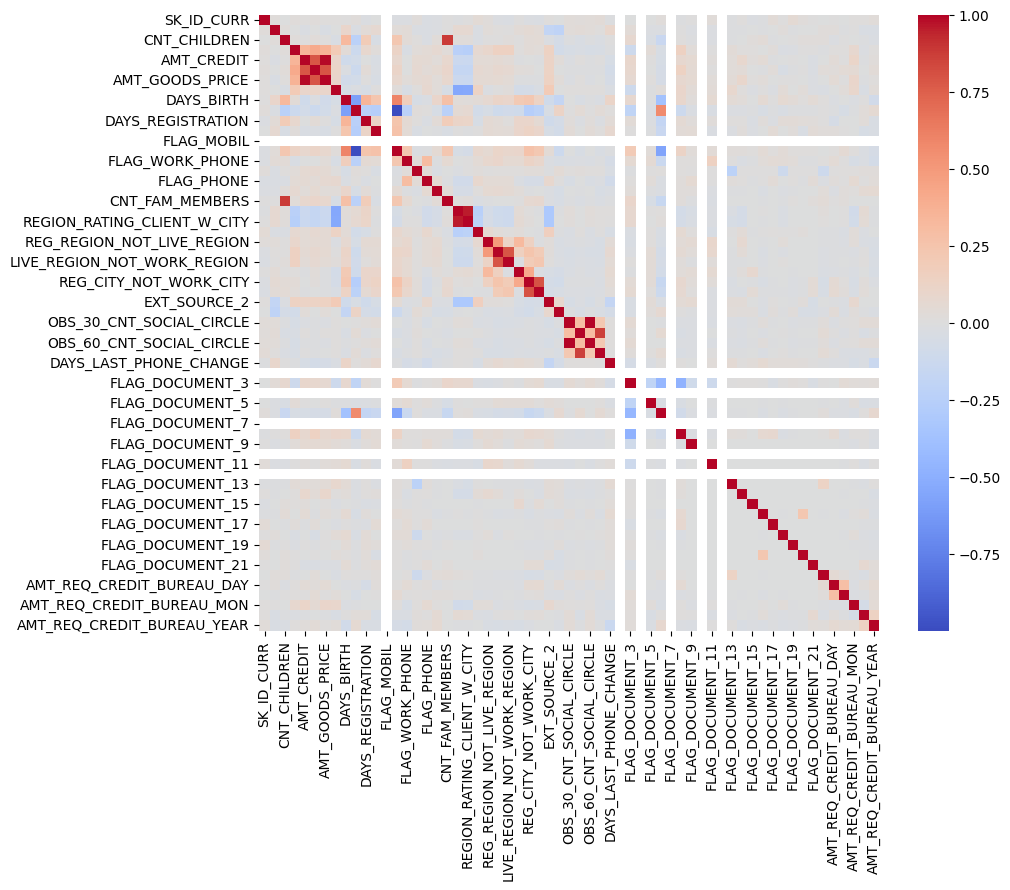

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

numeric_df = app_df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.show()

<Axes: ylabel='AMT_INCOME_TOTAL'>

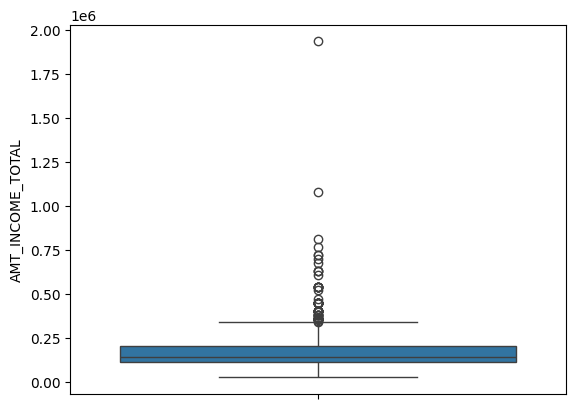

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(app_df['AMT_INCOME_TOTAL'])

In [22]:
app_df['TARGET'].value_counts()

,count
TARGET,
0.0,1782
1.0,140


<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

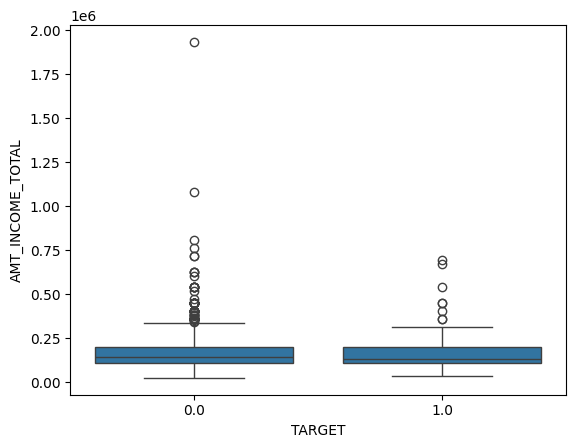

In [23]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=app_df)

<Axes: >

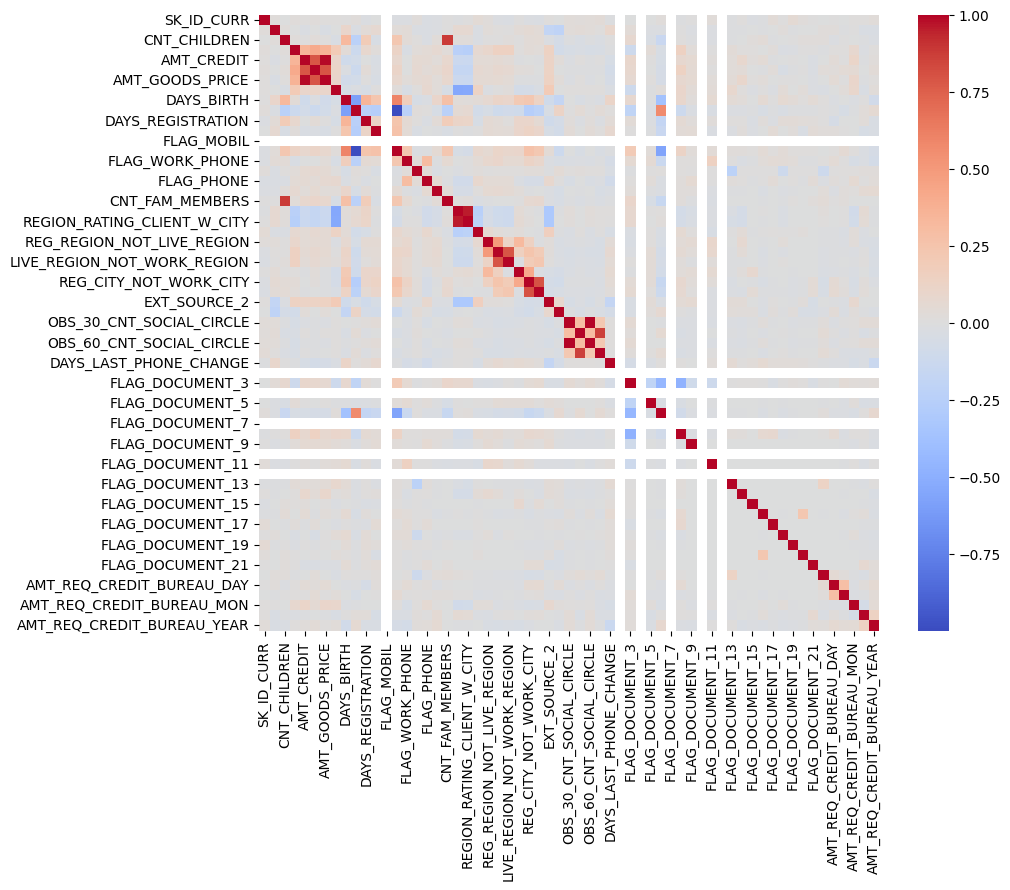

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(app_df.select_dtypes(include=['number']).corr(), cmap='coolwarm')